In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

In [4]:
model_name = "Qwen/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype='auto',
    device_map='auto'
)

In [6]:
from typing import Dict, TypedDict

In [7]:
class AgentState(TypedDict):
    operation: str
    op1: float
    op2: float
    finalAnswer: float
    stop: bool=False

In [23]:
def decide(state: AgentState) -> AgentState:
    if state['operation'] == 'add':
        return 'add_edge'
    elif state['operation'] == 'sub':
        return 'sub_edge'

In [24]:
def add(state: AgentState) -> AgentState:
    state['finalAnswer'] = state['op1'] + state['op2']
    return state

In [25]:
def sub(state: AgentState) -> AgentState:
    state['finalAnswer'] = state['op1'] - state['op2']
    return state

In [9]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage

In [11]:
AIMessage("olá")
HumanMessage("olá")

HumanMessage(content='olá', additional_kwargs={}, response_metadata={})

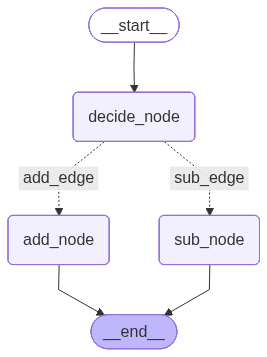

In [27]:
graph = StateGraph(AgentState)

graph.add_node('add_node', add)
graph.add_node('sub_node', sub)
graph.add_node('decide_node', lambda state: state)

graph.add_edge(START, 'decide_node')

graph.add_conditional_edges(
    'decide_node', decide,
    { # edge: node
        'add_edge': 'add_node',
        'sub_edge': 'sub_node'
    }
)

graph.add_edge('add_node', END)
graph.add_edge('sub_node', END)

app = graph.compile()
app

In [28]:
state1 = AgentState(op1=2, op2=3, operation='add')
app.invoke(state1)

{'operation': 'add', 'op1': 2, 'op2': 3, 'finalAnswer': 5}

In [ ]:
def greeting(state: AgentState) -> AgentState:
    print("Hello")
    return state

def Stop(state: AgentState)->AgentState:
    if state['stop']:
        

In [ ]:
graph = StateGraph(AgentState)


